In [21]:
# % pip install medmnist
# to download the dataset for the medmnist package

In [7]:
import torch 
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn 
import torchvision.models as models

In [15]:
from medmnist.dataset import PathMNIST
from medmnist import INFO

from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = PathMNIST(split='train', transform=transform, download=True)
val_dataset = PathMNIST(split='val', transform=transform, download=True)
test_dataset = PathMNIST(split='test', transform=transform, download=True)

data_flag = 'pathmnist'
info = INFO[data_flag]

Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz
Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz
Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz


### EDA

In [17]:
print("Dataset name:", data_flag)
print("Task:", info['task'])
print("Number of channels:", info['n_channels'])
print("Number of classes:", len(info['label']))
print("Labels:", info['label'])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Dataset name: pathmnist
Task: multi-class
Number of channels: 3
Number of classes: 9
Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Train size: 89996
Validation size: 10004
Test size: 7180


In [18]:
img, label = train_dataset[0]

print("Image shape:", img.shape)   # [C, H, W]
print("Label:", label)
print("Image min:", img.min().item())
print("Image max:", img.max().item())

Image shape: torch.Size([3, 28, 28])
Label: [0]
Image min: 0.6431372761726379
Image max: 0.8941176533699036


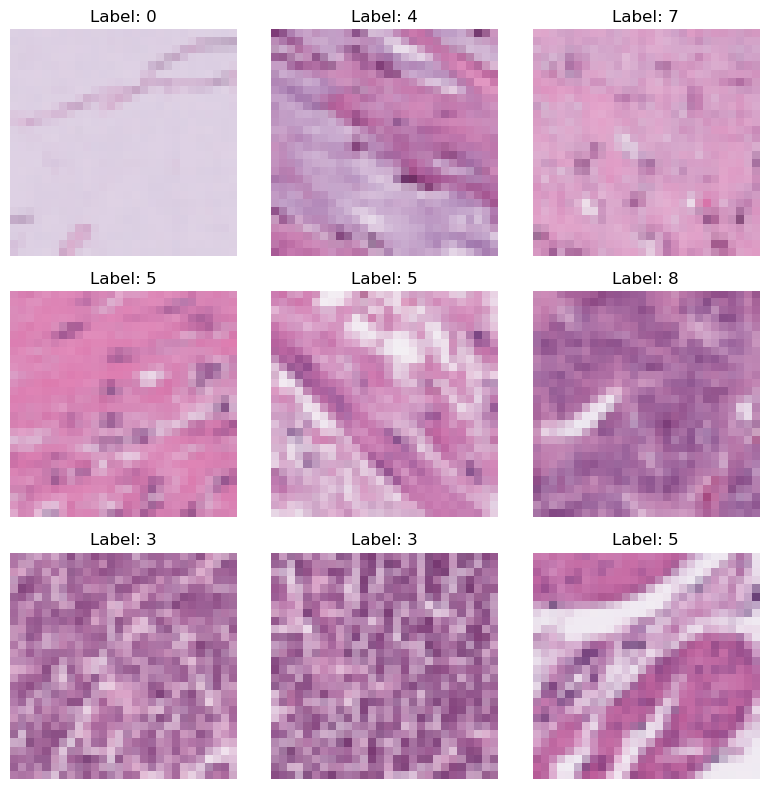

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    
    # PathMNIST usually has 3 channels, so transpose to HWC
    img_np = img.permute(1, 2, 0).numpy()
    
    ax.imshow(img_np)
    ax.set_title(f"Label: {label.item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Preprocessing

In [ ]:
# Normalized the pixel range from 0~1 to -1~1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5,0.5,0.5),
        std=(0.5,0.5,0.5)
    )
])

# Architecture Building 

In [ ]:
class pretrainVGG16_PathMNIST(nn.modules):
    def __init__(self, num_classes=9):
        # Override 
        super(pretrainVGG16_PathMNIST, self).__init__()
        
        # Load the pretrained VGG16
        self.vgg16 = models.vgg16(pretrained=True)

        # Freeze the layers of VGG16
        for para in self.vgg16.parameters():
            para.requires_grad = False

        # Replace the last fully connected layer with a new one
        # Make it fits the number of PM classes 
        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(
            in_features=in_features,
            out_features=num_classes
        ) 

    def forward(self, x):
        output = self.vgg16(x)
        return output



In [ ]:
class VGG16_PathMNIST(nn.modules):
    def __init__(self, num_classes=9):
        # Override 
        super(VGG16_PathMNIST, self).__init__()

        # VGG16 convolution blocks
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # classifier
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        output = self.classifier(x)
        return output



# Training and Hyper-parameter tuning 

# Evaluation with Validation

# Performace Metrics